# Projet CERCLE : Ajustement de cercles et d’ellipses par moindres carrés

## Shang MA et Yingxi YE  
### TP 1A  
### Mars 2026

# Plan du projet

- **1. Introduction**

- **2. Importation des bibliothèques**

- **3. Génération de données synthétiques**

- **4. Jeux de données de l’article**

- **5. Ajustement d’un cercle par méthode linéaire**
  - 5.1 Principe mathématique  
  - 5.2 Résolution numérique  
  - 5.3 Implémentation Python  
  - 5.4 Résultats et visualisation  
  - 5.5 Application au jeu de données 1  
  - 5.6 Analyse  

- **6. Ajustement géométrique non linéaire**
  - 6.1 Formulation du problème  
  - 6.2 Méthode numérique  
  - 6.3 Implémentation Python  
  - 6.4 Résultats  
  - 6.5 Application  
  - 6.6 Comparaison  

- **7. Ajustement avec contrainte**
  - 7.1 Formulation  
  - 7.2 Méthode  
  - 7.3 Implémentation  
  - 7.4 Résultats  
  - 7.5 Application  
  - 7.6 Comparaison  

- **8. Application au dataset 1**
  - 8.1 Description  
  - 8.2 Application  
  - 8.3 Analyse  

- **9. Ajustement d’une ellipse**
  - 9.1 Modèle mathématique  
  - 9.2 Ajustement algébrique  
  - 9.3 Conversion  
  - 9.4 Résultats  
  - 9.5 Raffinement (Newton)  
  - 9.6 Application dataset 2  
    - 9.6.1 Ajustement  
    - 9.6.2 Raffinement  
    - 9.6.3 Analyse  

- **10. Conclusion**

## 1. Introduction

L’objectif de ce projet est d’étudier plusieurs méthodes d’ajustement d’un cercle, puis de les étendre au cas de l’ellipse.

Dans une première partie, nous considérons trois approches pour ajuster un cercle à partir d’un nuage de points :
- une méthode linéaire par moindres carrés algébriques ;
- une méthode géométrique non linéaire ;
- une méthode géométrique avec contrainte.

Chaque méthode sera expliquée, implémentée en Python, puis testée sur des données synthétiques et sur le jeu de données fourni.

Dans une seconde partie, nous étendrons cette étude à l’ajustement d’une ellipse, en comparant plusieurs approches et en discutant leurs performances.

## 2. Importation des bibliothèques  

In [87]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares, minimize
import pandas as pd
from numpy.linalg import svd, eig, inv

In [88]:
# Paramètres d'affichage et reproductibilité
plt.rcParams["figure.figsize"] = (6, 6)
plt.rcParams["axes.grid"] = True
np.random.seed(42)

## 3. Génération de données synthétiques

Afin de tester les différentes méthodes d’ajustement, nous générons d’abord un jeu de données synthétique correspondant à un cercle de centre $(x_0, y_0)$ et de rayon $r$.

Les points sont répartis sur le cercle, puis perturbés par un bruit gaussien afin de simuler des données réelles.

Plus précisément :
- nous générons des angles uniformément répartis sur $[0, 2\pi]$ ;
- nous calculons les points du cercle exact ;
- nous ajoutons un bruit gaussien sur les coordonnées.

Cela permet d’évaluer la robustesse des méthodes en présence de bruit.

**Remarque :** ce jeu synthétique sert à valider les méthodes sur un cas contrôlé. Les jeux de données de l’article seront ensuite étudiés séparément.

In [89]:
# Données synthétiques : cercle bruité

# Paramètres du vrai cercle
x0_true = 2.0
y0_true = -1.0
r_true = 5.0

# Nombre de points
n_syn = 200

# Angles régulièrement répartis
theta_syn = np.linspace(0, 2*np.pi, n_syn, endpoint=False)

# Bruit gaussien
sigma = 0.2

# Génération des points bruités
x_syn = x0_true + r_true * np.cos(theta_syn) + sigma * np.random.randn(n_syn)
y_syn = y0_true + r_true * np.sin(theta_syn) + sigma * np.random.randn(n_syn)

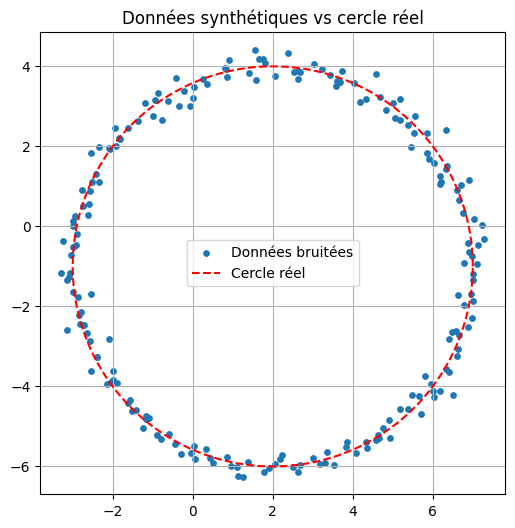

In [90]:
# Cercle réel (sans bruit) pour comparaison
theta_plot = np.linspace(0, 2*np.pi, 400)
x_true = x0_true + r_true * np.cos(theta_plot)
y_true = y0_true + r_true * np.sin(theta_plot)

plt.figure(figsize=(6, 6))
plt.scatter(x_syn, y_syn, label="Données bruitées", s=15)
plt.plot(x_true, y_true, 'r--', label="Cercle réel")
plt.axis("equal")
plt.grid(True)
plt.title("Données synthétiques vs cercle réel")
plt.legend()
plt.show()

## 4. Jeux de données de l’article

En plus du jeu synthétique, on utilise les jeux de données fournis dans l’article de Gander, Golub et Strebel.

- Le **jeu de données 1** correspond à un ajustement de cercle.
- Le **jeu de données 2** correspond à un ajustement d’ellipse.

Ces données serviront à comparer les méthodes algébriques et géométriques.

In [91]:
file_path = "data_cercle"  

data1 = []
data2 = []
current = None

with open(file_path, "r") as f:
    for line in f:
        line = line.strip()
        if not line:
            continue
        
        if line.startswith("#data 1"):
            current = data1
            continue
        elif line.startswith("#data 2"):
            current = data2
            continue
        
        x, y = map(float, line.split())
        current.append([x, y])

data1 = np.array(data1)
data2 = np.array(data2)

x_data1, y_data1 = data1[:, 0], data1[:, 1]
x_data2, y_data2 = data2[:, 0], data2[:, 1]

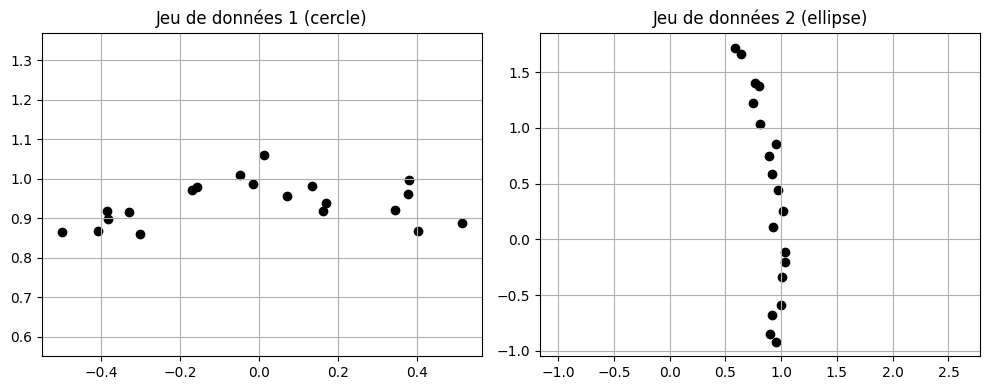

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

# Jeu de données 1 (cercle)
axes[0].scatter(x_data1, y_data1, color="black")
axes[0].set_title("Jeu de données 1 (cercle)")
axes[0].axis("equal")
axes[0].grid(True)

# Jeu de données 2 (ellipse)
axes[1].scatter(x_data2, y_data2, color="black")
axes[1].set_title("Jeu de données 2 (ellipse)")
axes[1].axis("equal")
axes[1].grid(True)

plt.tight_layout()
plt.show()

### Remarque

On observe que les points du jeu de données 1 et du jeu de données 2 ne forment pas visuellement un cercle ou une ellipse évidente.

Cela s’explique par le faible nombre de points et leur répartition irrégulière.

Ainsi, il est nécessaire d’utiliser des méthodes d’ajustement (algébriques ou géométriques) afin de déterminer le cercle ou l’ellipse qui approxime le mieux ces données.

## 5. Ajustement d’un cercle par méthode linéaire  

###  5.1 Principe mathématique — Ajustement d’un cercle (moindres carrés)

####  1）Forme algébrique du cercle

On considère l’équation générale d’un cercle :

$$
x^2 + y^2 + ax + by + c = 0.
$$

Soit un ensemble de points $(x_i, y_i)_{i=1}^n$.  
On cherche les paramètres $(a,b,c)$ qui minimisent l’erreur algébrique :

$$
\min_{a,b,c} \sum_{i=1}^n \left(x_i^2 + y_i^2 + a x_i + b y_i + c\right)^2.
$$

En pratique, les points ne vérifient pas exactement l’équation du cercle à cause du bruit dans les données.

Ainsi, la quantité  
$$
x_i^2 + y_i^2 + ax_i + by_i + c
$$  
mesure l’écart à l’équation du cercle et peut être interprétée comme un résidu algébrique.

On cherche donc à minimiser la somme des carrés de ces résidus, ce qui conduit naturellement à un problème de moindres carrés.

Il est important de noter que cette approche repose sur une distance algébrique et non sur la distance géométrique réelle au cercle, ce qui permet d’obtenir un problème linéaire plus simple à résoudre.

---

#### 2）Mise sous forme linéaire (moindres carrés)

On réécrit l’équation sous forme linéaire en $(a,b,c)$ :

$$
a x_i + b y_i + c \approx -(x_i^2 + y_i^2).
$$

Cette approximation provient du fait que les points ne vérifient pas exactement l’équation du cercle, en raison du bruit ou de l’imperfection des données. On cherche donc une solution au sens des moindres carrés.

Ce qui conduit au système matriciel :

$$
A \theta \simeq d, \quad \text{avec } \theta =
\begin{pmatrix}
a \\ b \\ c
\end{pmatrix}
$$

où

$$
A =
\begin{pmatrix}
x_1 & y_1 & 1 \\
x_2 & y_2 & 1 \\
\vdots & \vdots & \vdots \\
x_n & y_n & 1
\end{pmatrix},
\qquad
d =
\begin{pmatrix}
-(x_1^2+y_1^2) \\
-(x_2^2+y_2^2) \\
\vdots \\
-(x_n^2+y_n^2)
\end{pmatrix}.
$$

On résout alors le problème des moindres carrés :

$$
\min_{\theta} \|A\theta - d\|^2.
$$

Cette méthode minimise une erreur algébrique, et non la distance géométrique réelle entre les points et le cercle. Elle est plus simple mais peut être moins précise.

---

#### 3）Lien avec la forme géométrique du cercle

La forme géométrique d’un cercle est :

$$
(x - x_0)^2 + (y - y_0)^2 = r^2.
$$

En développant :

$$
x^2 - 2x_0 x + x_0^2 + y^2 - 2y_0 y + y_0^2 = r^2,
$$

soit :

$$
x^2 + y^2 - 2x_0 x - 2y_0 y + (x_0^2 + y_0^2 - r^2) = 0.
$$

---

#### 4）Identification des paramètres

En comparant avec :

$$
x^2 + y^2 + ax + by + c = 0,
$$

on obtient :

$$
a = -2x_0, \quad b = -2y_0, \quad c = x_0^2 + y_0^2 - r^2.
$$

---

#### 5）Expression du centre et du rayon

##### Centre :
$$
x_0 = -\frac{a}{2}, \qquad y_0 = -\frac{b}{2}.
$$

##### Rayon :

À partir de :

$$
c = x_0^2 + y_0^2 - r^2,
$$

on obtient :

$$
r^2 = x_0^2 + y_0^2 - c.
$$

En remplaçant $x_0, y_0$ :

$$
r^2 = \frac{a^2}{4} + \frac{b^2}{4} - c,
$$

donc :

$$
r = \sqrt{\frac{a^2 + b^2}{4} - c}.
$$

---

## Conclusion

Le problème d’ajustement d’un cercle est ramené à un problème de moindres carrés linéaire en $(a,b,c)$, dont la solution permet ensuite de retrouver directement les paramètres géométriques $(x_0, y_0, r)$.

### 5.2 Résolution numérique

Le problème précédent est un problème de moindres carrés :

$$
\min_{\theta} \|A\theta - d\|^2.
$$

Une solution classique est donnée par les équations normales :

$$
A^T A \theta = A^T d,
$$

d’où :

$$
\theta = (A^T A)^{-1} A^T d,
$$

si $A^T A$ est inversible.

En pratique, on utilise des méthodes numériques plus stables, comme la décomposition QR, la SVD ou des fonctions dédiées (par exemple `numpy.linalg.lstsq`), afin d’obtenir une solution fiable.

### 5.3 Implémentation Python

Nous implémentons la méthode des moindres carrés en utilisant la fonction `numpy.linalg.lstsq`, qui permet de résoudre directement le problème :

$$
\min_{\theta} \|A\theta - d\|^2.
$$

In [93]:
def fit_circle_linear(x, y):
    """
    Ajustement algébrique d’un cercle par moindres carrés.
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    A = np.column_stack([x, y, np.ones_like(x)])
    d = -(x**2 + y**2)

    sol, _, _, _ = np.linalg.lstsq(A, d, rcond=None)
    a, b, c = sol

    x0 = -a / 2
    y0 = -b / 2
    radicand = (a**2 + b**2) / 4 - c
    r = np.sqrt(max(radicand, 0.0))

    return a, b, c, x0, y0, r

### 5.4 Résultats et visualisation sur les données synthétiques

Nous présentons ci-dessous les résultats de l’ajustement du cercle par la méthode des moindres carrés algébriques sur le jeu de données synthétique.

Les paramètres estimés $(x_0, y_0, r)$ sont comparés aux valeurs réelles utilisées pour générer les données.

La figure suivante montre les points bruités, ainsi que le cercle estimé et le cercle réel.

In [94]:
# Ajustement du cercle sur les données synthétiques
a_est, b_est, c_est, x0_est, y0_est, r_est = fit_circle_linear(x_syn, y_syn)

# Affichage des résultats
print("Paramètres algébriques estimés :")
print(f"a = {a_est:.4f}")
print(f"b = {b_est:.4f}")
print(f"c = {c_est:.4f}")

print("\nParamètres géométriques estimés :")
print(f"Centre estimé : ({x0_est:.4f}, {y0_est:.4f})")
print(f"Rayon estimé  : {r_est:.4f}")

print("\nParamètres réels :")
print(f"Centre réel : ({x0_true:.4f}, {y0_true:.4f})")
print(f"Rayon réel  : {r_true:.4f}")

Paramètres algébriques estimés :
a = -3.9906
b = 2.0266
c = -19.9757

Paramètres géométriques estimés :
Centre estimé : (1.9953, -1.0133)
Rayon estimé  : 4.9984

Paramètres réels :
Centre réel : (2.0000, -1.0000)
Rayon réel  : 5.0000


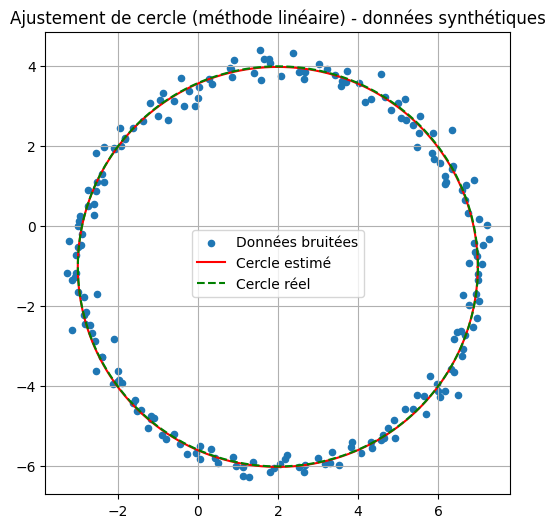

In [95]:
theta_plot = np.linspace(0, 2*np.pi, 400)

# Cercle estimé
x_circle_est = x0_est + r_est * np.cos(theta_plot)
y_circle_est = y0_est + r_est * np.sin(theta_plot)

# Cercle réel
x_circle_true = x0_true + r_true * np.cos(theta_plot)
y_circle_true = y0_true + r_true * np.sin(theta_plot)

plt.figure(figsize=(6, 6))
plt.scatter(x_syn, y_syn, label="Données bruitées", s=20)
plt.plot(x_circle_est, y_circle_est, 'r-', label="Cercle estimé")
plt.plot(x_circle_true, y_circle_true, 'g--', label="Cercle réel")

plt.axis('equal')
plt.grid(True)
plt.legend()
plt.title("Ajustement de cercle (méthode linéaire) - données synthétiques")
plt.show()

### 5.5 Application au jeu de données 1 

Nous appliquons maintenant la méthode des moindres carrés algébriques au jeu de données 1 extrait de l’article de Gander, Golub et Strebel.

Contrairement aux données synthétiques, les paramètres réels du cercle ne sont pas connus. L’objectif est donc d’estimer au mieux le cercle qui ajuste ces points.

In [96]:
# Ajustement du cercle
a1, b1, c1, x0_1, y0_1, r1 = fit_circle_linear(x_data1, y_data1)

# Résultats
print("Paramètres estimés (jeu de données 1) :")
print(f"Centre estimé : ({x0_1:.4f}, {y0_1:.4f})")
print(f"Rayon estimé  : {r1:.4f}")

Paramètres estimés (jeu de données 1) :
Centre estimé : (0.0206, 0.3982)
Rayon estimé  : 0.6233


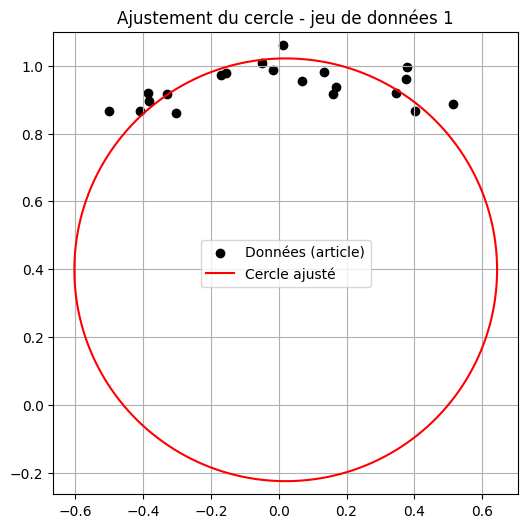

In [97]:
theta_plot = np.linspace(0, 2*np.pi, 400)

x_circle1 = x0_1 + r1 * np.cos(theta_plot)
y_circle1 = y0_1 + r1 * np.sin(theta_plot)

plt.figure(figsize=(6, 6))
plt.scatter(x_data1, y_data1, color='black', label="Données (article)")
plt.plot(x_circle1, y_circle1, 'r-', label="Cercle ajusté")

plt.axis('equal')
plt.grid(True)
plt.legend()
plt.title("Ajustement du cercle - jeu de données 1")
plt.show()

### 5.6 Analyse 

Sur les données synthétiques, la méthode des moindres carrés algébriques permet d’estimer avec précision le centre et le rayon du cercle. Les résultats sont très proches des valeurs réelles, ce qui valide l’implémentation.

Cependant, cette méthode repose sur la minimisation d’une erreur algébrique et non d’une distance géométrique. Ainsi, même si les résultats sont satisfaisants dans le cas synthétique, ils ne garantissent pas un ajustement optimal au sens géométrique.

Sur le jeu de données 1 de l’article, la méthode fournit un cercle qui semble bien ajuster les points, malgré le faible nombre de données et leur répartition non uniforme. Toutefois, en l’absence de solution de référence, il est difficile d’évaluer précisément la qualité de l’ajustement.

Ces observations motivent l’introduction d’une méthode géométrique non linéaire, qui sera étudiée dans la suite du projet.

## 6. Ajustement géométrique non linéaire

### 6.1 Formulation du problème

Contrairement à la méthode algébrique, on cherche ici à minimiser une distance géométrique réelle entre les points et le cercle.

Le problème s’écrit :

$$
\min_{x_c, y_c, r} \sum_{i=1}^n \left(\sqrt{(x_i - x_c)^2 + (y_i - y_c)^2} - r\right)^2.
$$

Il s’agit d’un problème de moindres carrés non linéaire, car les paramètres $(x_c, y_c, r)$ apparaissent de manière non linéaire.

### 6.2 Méthode numérique

Ce problème ne peut pas être résolu directement par des méthodes linéaires.

On utilise donc une méthode d’optimisation numérique, qui consiste à minimiser une fonction de coût définie comme la somme des erreurs géométriques.

En pratique, on utilise des algorithmes itératifs (par exemple la méthode de Gauss-Newton ou des fonctions d’optimisation comme `scipy.optimize.least_squares`) pour trouver les paramètres optimaux.Le choix d’une bonne initialisation est important, car il influence la convergence de la méthode non linéaire.

### 6.3 Implémentation Python

In [98]:
from scipy.optimize import least_squares

def fit_circle_geometric(x, y):
    """
    Ajustement d’un cercle par moindres carrés géométriques
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # Fonction résiduelle
    def residuals(params):
        xc, yc, r = params
        return np.sqrt((x - xc)**2 + (y - yc)**2) - r

    # Initialisation à partir de la méthode algébrique
    _, _, _, x0_init, y0_init, r_init = fit_circle_linear(x, y)
    initial_guess = [x0_init, y0_init, r_init]

    # Optimisation
    result = least_squares(residuals, initial_guess)

    xc, yc, r = result.x
    return xc, yc, r

### 6.4 Résultats et visualisation sur les données synthétiques

Nous appliquons maintenant la méthode géométrique non linéaire au jeu de données synthétique.

Les paramètres estimés sont comparés aux valeurs réelles utilisées pour générer les données. La figure suivante montre les points bruités, ainsi que le cercle géométrique estimé et le cercle réel.

In [99]:
x0_geo, y0_geo, r_geo = fit_circle_geometric(x_syn, y_syn)

print("Méthode géométrique :")
print(f"Centre estimé : ({x0_geo:.4f}, {y0_geo:.4f})")
print(f"Rayon estimé  : {r_geo:.4f}")

print("\nValeurs réelles :")
print(f"Centre réel : ({x0_true:.4f}, {y0_true:.4f})")
print(f"Rayon réel  : {r_true:.4f}")

Méthode géométrique :
Centre estimé : (1.9935, -1.0174)
Rayon estimé  : 4.9948

Valeurs réelles :
Centre réel : (2.0000, -1.0000)
Rayon réel  : 5.0000


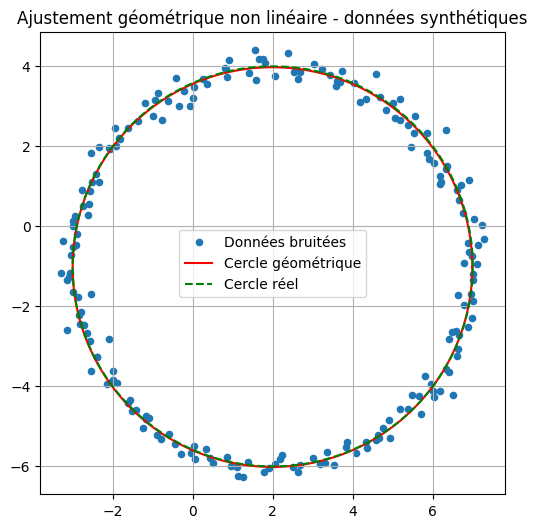

In [100]:
theta_plot = np.linspace(0, 2*np.pi, 400)

# Cercle géométrique estimé
x_geo_circle = x0_geo + r_geo * np.cos(theta_plot)
y_geo_circle = y0_geo + r_geo * np.sin(theta_plot)

# Cercle réel
x_true_circle = x0_true + r_true * np.cos(theta_plot)
y_true_circle = y0_true + r_true * np.sin(theta_plot)

plt.figure(figsize=(6, 6))
plt.scatter(x_syn, y_syn, label="Données bruitées", s=20)
plt.plot(x_geo_circle, y_geo_circle, 'r-', label="Cercle géométrique")
plt.plot(x_true_circle, y_true_circle, 'g--', label="Cercle réel")

plt.axis('equal')
plt.grid(True)
plt.legend()
plt.title("Ajustement géométrique non linéaire - données synthétiques")
plt.show()

Sur le jeu de données synthétique, la méthode géométrique fournit une estimation très proche du cercle réel. Cela confirme que la minimisation directe de la distance géométrique permet d’obtenir un ajustement précis lorsque les données sont modérément bruitées.

### 6.5 Application au jeu de données 1 

Nous appliquons maintenant la méthode géométrique non linéaire au jeu de données 1 extrait de l’article de Gander, Golub et Strebel.

Contrairement aux données synthétiques, les paramètres réels du cercle ne sont pas connus. L’objectif est donc d’obtenir le meilleur ajustement possible des points.

In [101]:
x0_geo_1, y0_geo_1, r_geo_1 = fit_circle_geometric(x_data1, y_data1)

print("Méthode géométrique - jeu de données 1 :")
print(f"Centre estimé : ({x0_geo_1:.4f}, {y0_geo_1:.4f})")
print(f"Rayon estimé  : {r_geo_1:.4f}")

Méthode géométrique - jeu de données 1 :
Centre estimé : (0.0404, -0.0949)
Rayon estimé  : 1.0789


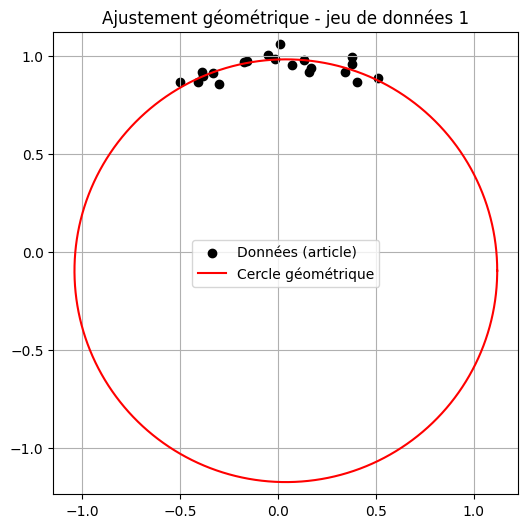

In [102]:
theta_plot = np.linspace(0, 2*np.pi, 400)

x_circle_geo1 = x0_geo_1 + r_geo_1 * np.cos(theta_plot)
y_circle_geo1 = y0_geo_1 + r_geo_1 * np.sin(theta_plot)

plt.figure(figsize=(6, 6))
plt.scatter(x_data1, y_data1, color='black', label="Données (article)")
plt.plot(x_circle_geo1, y_circle_geo1, 'r-', label="Cercle géométrique")

plt.axis('equal')
plt.grid(True)
plt.legend()
plt.title("Ajustement géométrique - jeu de données 1")
plt.show()

Sur ce jeu de données réel, la méthode géométrique fournit un cercle qui ajuste correctement les points, malgré leur faible nombre et leur répartition irrégulière.

En l’absence de solution exacte, l’évaluation se fait visuellement : le cercle obtenu semble cohérent avec la distribution des données.

### 6.6 Comparaison avec la méthode linéaire

La méthode algébrique est simple, rapide et facile à implémenter, car elle repose sur la résolution d’un système linéaire.

La méthode géométrique, en revanche, minimise directement la distance euclidienne entre les points et le cercle. Elle fournit donc en général un ajustement plus fidèle au sens géométrique.

Cependant, cette méthode est plus coûteuse en calcul, car elle nécessite une optimisation itérative et dépend du choix de l’initialisation.

Dans ce projet :
- la méthode algébrique fournit une bonne estimation initiale ;
- la méthode géométrique permet d’améliorer la précision de l’ajustement.

## 7. Ajustement avec contrainte

### 7.1 Formulation avec contrainte

On considère maintenant une variante du problème géométrique dans laquelle on impose qu’un point donné $(x_n, y_n)$ appartienne exactement au cercle.

Le problème devient :

$$
\min_{x_c, y_c, r} \sum_{i=1}^{n-1} \left(\sqrt{(x_i - x_c)^2 + (y_i - y_c)^2} - r\right)^2
$$

sous la contrainte :

$$
(x_n - x_c)^2 + (y_n - y_c)^2 = r^2.
$$

Cette contrainte garantit que le dernier point est exactement situé sur le cercle.

### 7.2 Méthode de résolution

On utilise la contrainte pour exprimer le rayon en fonction du centre :

$$
r = \sqrt{(x_n - x_c)^2 + (y_n - y_c)^2}.
$$

Le problème devient alors un problème d’optimisation non linéaire en $(x_c, y_c)$ uniquement.

On minimise :

$$
\sum_{i=1}^{n-1} \left(\sqrt{(x_i - x_c)^2 + (y_i - y_c)^2} - r(x_c, y_c)\right)^2.
$$

Ce problème est résolu numériquement à l’aide d’une méthode d’optimisation.

### 7.3 Implémentation Python

In [103]:
def fit_circle_constrained(x, y):
    """
    Ajustement avec contrainte :
    le dernier point appartient exactement au cercle
    """

    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    # Point contraint
    x_n, y_n = x[-1], y[-1]

    def residuals(params):
        xc, yc = params

        # rayon imposé
        r = np.sqrt((x_n - xc)**2 + (y_n - yc)**2)

        # erreurs autres points
        distances = np.sqrt((x[:-1] - xc)**2 + (y[:-1] - yc)**2)

        return distances - r

    # Initialisation avec méthode géométrique
    x0_init, y0_init, _ = fit_circle_geometric(x, y)

    result = least_squares(residuals, [x0_init, y0_init])

    xc, yc = result.x
    r = np.sqrt((x_n - xc)**2 + (y_n - yc)**2)

    return xc, yc, r

### 7.4 Résultats et visualisation sur les données synthétiques

In [104]:
x0_con, y0_con, r_con = fit_circle_constrained(x_syn, y_syn)

print("Méthode avec contrainte :")
print(f"Centre estimé : ({x0_con:.4f}, {y0_con:.4f})")
print(f"Rayon estimé  : {r_con:.4f}")

Méthode avec contrainte :
Centre estimé : (1.8481, -1.0196)
Rayon estimé  : 4.9221


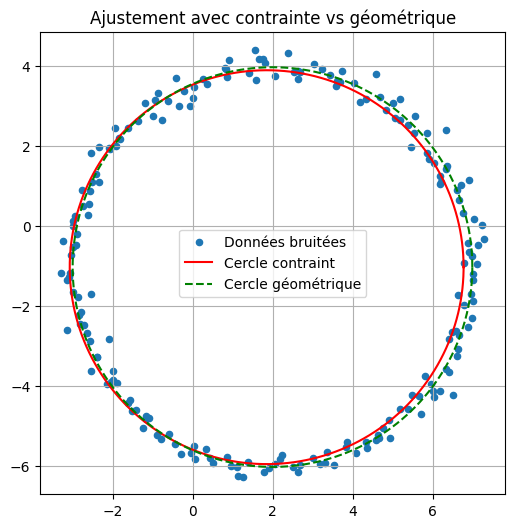

In [105]:
theta_plot = np.linspace(0, 2*np.pi, 400)

# Cercle contraint
x_con_circle = x0_con + r_con * np.cos(theta_plot)
y_con_circle = y0_con + r_con * np.sin(theta_plot)

# Cercle géométrique (méthode 2)
x_geo_circle = x0_geo + r_geo * np.cos(theta_plot)
y_geo_circle = y0_geo + r_geo * np.sin(theta_plot)

plt.figure(figsize=(6, 6))
plt.scatter(x_syn, y_syn, label="Données bruitées", s=20)

plt.plot(x_con_circle, y_con_circle, 'r-', label="Cercle contraint")
plt.plot(x_geo_circle, y_geo_circle, 'g--', label="Cercle géométrique")

plt.axis('equal')
plt.grid(True)
plt.legend()
plt.title("Ajustement avec contrainte vs géométrique")
plt.show()

L’ajout de la contrainte modifie légèrement le cercle estimé afin de satisfaire exactement la condition imposée. On observe que le cercle passe précisément par le point contraint, au détriment d’un ajustement global légèrement moins optimal.

### 7.5 Application au jeu de données 1 

Nous appliquons également la méthode avec contrainte au jeu de données 1 afin d’observer l’impact de la contrainte sur des données réelles.

In [106]:
x0_con_1, y0_con_1, r_con_1 = fit_circle_constrained(x_data1, y_data1)

print("Méthode avec contrainte - jeu de données 1 :")
print(f"Centre estimé : ({x0_con_1:.4f}, {y0_con_1:.4f})")
print(f"Rayon estimé  : {r_con_1:.4f}")

Méthode avec contrainte - jeu de données 1 :
Centre estimé : (0.0276, -0.3082)
Rayon estimé  : 1.2873


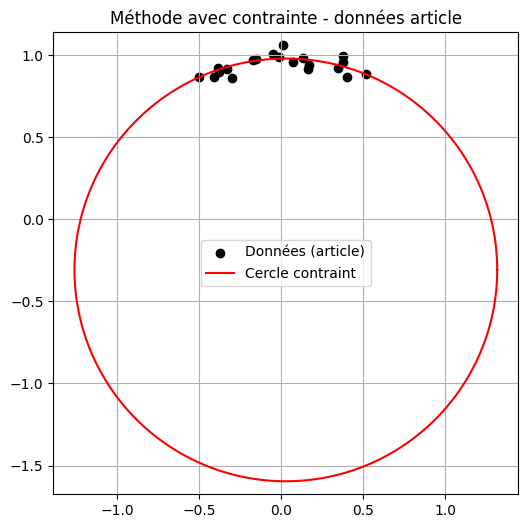

In [107]:
theta_plot = np.linspace(0, 2*np.pi, 400)

x_circle_con1 = x0_con_1 + r_con_1 * np.cos(theta_plot)
y_circle_con1 = y0_con_1 + r_con_1 * np.sin(theta_plot)

plt.figure(figsize=(6, 6))
plt.scatter(x_data1, y_data1, color='black', label="Données (article)")
plt.plot(x_circle_con1, y_circle_con1, 'r-', label="Cercle contraint")

plt.axis('equal')
plt.grid(True)
plt.legend()
plt.title("Méthode avec contrainte - données article")
plt.show()

### 7.6 Comparaison avec la méthode géométrique

Nous comparons ici l’ajustement avec contrainte et l’ajustement géométrique
sans contrainte, appliqués au même jeu de données.

L’ajustement géométrique consiste à minimiser la somme des carrés des distances
entre les points et le cercle. Cette méthode prend en compte l’ensemble des
données de manière équilibrée et fournit généralement une solution robuste.

En revanche, l’ajustement avec contrainte impose que l’un des points appartienne
exactement au cercle. Cette contrainte peut influencer fortement le résultat,
en particulier si le point choisi est bruité ou atypique.

En pratique, nous observons que :
- l’ajustement géométrique donne un cercle plus homogène visuellement ;
- l’ajustement avec contrainte peut produire un cercle légèrement décalé,
  car il privilégie la satisfaction de la contrainte.

Ainsi, l’ajustement géométrique est généralement préférable lorsqu’on cherche
une approximation globale des données, tandis que l’ajustement avec contrainte
peut être utile lorsque certaines conditions doivent être strictement respectées.

## 8. Application au dataset 1

Dans cette partie, nous appliquons les différentes méthodes d’ajustement étudiées précédemment (méthode linéaire, ajustement géométrique et ajustement avec contrainte) à un jeu de données donné.

L’objectif est d’évaluer et de comparer leurs performances dans un contexte concret, en analysant la précision des estimations du centre et du rayon du cercle.

Nous décrivons d’abord les données, puis nous appliquons les différentes méthodes, avant de proposer une analyse comparative des résultats.

### 8.1 Description des données

Le jeu de données utilisé est constitué de points $(x_i, y_i)$ supposés appartenir approximativement à un cercle, éventuellement perturbés par du bruit.

Dans certains cas, les paramètres du cercle de référence (centre et rayon) sont connus, ce qui permet d’évaluer quantitativement les performances des différentes méthodes d’ajustement.

### 8.2 Application des différentes méthodes

Nous appliquons successivement les trois méthodes d’ajustement étudiées :

- la méthode des moindres carrés linéaires ;
- l’ajustement géométrique non linéaire ;
- l’ajustement avec contrainte.

Pour chacune de ces méthodes, nous estimons les paramètres du cercle, à savoir le centre $(x_0, y_0)$ et le rayon $r$.

Les résultats obtenus sont ensuite comparés dans la section suivante.

### 8.3 Analyse comparative

Afin de comparer les différentes méthodes d’ajustement, nous évaluons les erreurs sur le centre et le rayon par rapport au cercle de référence.

Le tableau suivant résume les résultats obtenus :

In [108]:
def compute_errors(x_est, y_est, r_est, x_true, y_true, r_true):
    # erreur centre (distance euclidienne)
    err_center = np.sqrt((x_est - x_true)**2 + (y_est - y_true)**2)
    # erreur rayon
    err_radius = abs(r_est - r_true)
    
    return err_center, err_radius

# Construction des résultats
results = []

methods = [("Linéaire", x0_est, y0_est, r_est),("Géométrique", x0_geo, y0_geo, r_geo),("Contrainte", x0_con, y0_con, r_con)]

for name, x, y, r in methods:
    err_c = np.sqrt((x - x0_true)**2 + (y - y0_true)**2)
    err_r = abs(r - r_true)
    results.append([name, x, y, r, err_c, err_r])

# DataFrame méthodes
df = pd.DataFrame(results, columns=["Méthode","x0", "y0","r","Erreur centre","Erreur rayon"])

# Ajout du vrai cercle
df_true = pd.DataFrame([["Vrai cercle",x0_true, y0_true, r_true, 0, 0]], columns=df.columns)

# Fusion
df_all = pd.concat([df_true, df], ignore_index=True)

# Affichage
df_all.round(4)

,Méthode,x0,y0,r,Erreur centre,Erreur rayon
0,Vrai cercle,2.0000,-1.0000,5.0000,0.0000,0.0000
1,Linéaire,1.9953,-1.0133,4.9984,0.0141,0.0016
2,Géométrique,1.9935,-1.0174,4.9948,0.0186,0.0052
3,Contrainte,1.8481,-1.0196,4.9221,0.1532,0.0779


# 9. Ajustement d’une ellipse

## 9.1 Modèle mathématique

On considère un ensemble de points $(x_i, y_i)$ dans le plan.  
On cherche à ajuster une ellipse passant au mieux près de ces points.

Une ellipse peut être décrite par l’équation implicite :

$$
Ax^2 + Bxy + Cy^2 + Dx + Ey + F = 0
$$

avec la condition :

$$
B^2 - 4AC < 0
$$

qui garantit que la conique obtenue est bien une ellipse.

---

## Génération des données elliptiques

On utilise une représentation paramétrique de l’ellipse :

$$
\begin{cases}
x = x_c + a\cos t \cos\theta - b\sin t \sin\theta \\
y = y_c + a\cos t \sin\theta + b\sin t \cos\theta
\end{cases}
$$

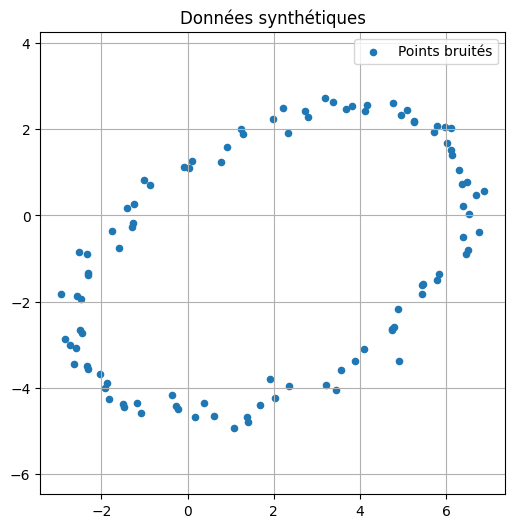

In [109]:
# Paramètres réels de l'ellipse
xc_true, yc_true = 2.0, -1.0
a_true, b_true = 5.0, 3.0
theta_true = np.deg2rad(30)

n = 100
t = np.linspace(0, 2*np.pi, n, endpoint=False)

x_clean = xc_true + a_true * np.cos(t) * np.cos(theta_true) - b_true * np.sin(t) * np.sin(theta_true)
y_clean = yc_true + a_true * np.cos(t) * np.sin(theta_true) + b_true * np.sin(t) * np.cos(theta_true)

# Ajout d'un bruit
sigma = 0.2
x = x_clean + sigma * np.random.randn(n)
y = y_clean + sigma * np.random.randn(n)

plt.figure(figsize=(6, 6))
plt.scatter(x, y, s=20, label="Points bruités")
plt.axis("equal")
plt.legend()
plt.title("Données synthétiques")
plt.show()

## 9.2 Ajustement algébrique (forme linéaire)

Pour chaque point $(x_i, y_i)$, on écrit :

$$
Ax_i^2 + Bx_i y_i + Cy_i^2 + Dx_i + Ey_i + F \approx 0
$$

On construit alors la matrice :

$$
M =
\begin{pmatrix}
x_1^2 & x_1 y_1 & y_1^2 & x_1 & y_1 & 1 \\
\vdots & \vdots & \vdots & \vdots & \vdots & \vdots \\
x_n^2 & x_n y_n & y_n^2 & x_n & y_n & 1
\end{pmatrix}
$$

et on cherche un vecteur non nul $p = (A,B,C,D,E,F)^T$ minimisant $\|Mp\|$.

En pratique, la solution est donnée par le vecteur singulier associé à la plus petite valeur singulière de $M$.

In [110]:
def fit_ellipse_algebraic(x, y):
    """
    Ajustement algébrique d'une conique :
    Ax^2 + Bxy + Cy^2 + Dx + Ey + F = 0
    """
    M = np.column_stack((x**2, x*y, y**2, x, y, np.ones_like(x)))
    _, _, Vt = svd(M)
    p = Vt[-1, :]
    return p  # A, B, C, D, E, F

In [111]:
A, B, C, D, E, F = fit_ellipse_algebraic(x, y)

print("Paramètres algébriques :")
print(f"A = {A:.6f}")
print(f"B = {B:.6f}")
print(f"C = {C:.6f}")
print(f"D = {D:.6f}")
print(f"E = {E:.6f}")
print(f"F = {F:.6f}")

disc = B**2 - 4*A*C
print(f"\nDiscriminant B^2 - 4AC = {disc:.6f}")

if disc < 0:
    print("La conique obtenue est compatible avec une ellipse.")
else:
    print("Attention : la conique obtenue n'est pas une ellipse.")

Paramètres algébriques :
A = -0.079227
B = 0.083387
C = -0.130798
D = 0.397298
E = -0.438943
F = 0.786857

Discriminant B^2 - 4AC = -0.034498
La conique obtenue est compatible avec une ellipse.


## 9.3 Conversion d’une conique en paramètres géométriques

On considère une conique donnée sous forme implicite :

$$
Ax^2 + Bxy + Cy^2 + Dx + Ey + F = 0
$$

L’objectif est d’en extraire les paramètres géométriques :
- centre $(x_c, y_c)$
- demi-axes $(a, b)$
- angle de rotation $\theta$

---

### 1. Écriture matricielle

On réécrit l’équation sous forme quadratique :

$$
x^T Q x + d^T x + F = 0
$$

avec :

$$
Q =
\begin{bmatrix}
A & B/2 \\
B/2 & C
\end{bmatrix},
\quad
d =
\begin{bmatrix}
D \\
E
\end{bmatrix}
$$

---

### 2. Calcul du centre

Le centre correspond au point où le gradient s’annule :

$$
2Qx + d = 0
$$

d’où :

$$
x_c = -\frac{1}{2} Q^{-1} d
$$

---

### 3. Translation au centre

Après changement de variable $x = x' + x_c$, on obtient:

$$
(x')^T Q x' + F_c = 0
$$

avec :

$$
F_c = F + x_c^T Q x_c + d^T x_c
$$

Cette étape supprime les termes linéaires.

---

### 4. Diagonalisation de $Q$

On effectue une décomposition spectrale :

$$
Q = V \Lambda V^T
$$

où :
- $\Lambda = \mathrm{diag}(\lambda_1, \lambda_2)$
- $V$ contient les vecteurs propres

Cela correspond à une rotation du repère vers les axes principaux.

---

### 5. Forme canonique

Dans le repère diagonal :

$$
\lambda_1 x'^2 + \lambda_2 y'^2 + F_c = 0
$$

On réécrit :

$$
\frac{x'^2}{-F_c / \lambda_1} + \frac{y'^2}{-F_c / \lambda_2} = 1
$$

---

### 6. Demi-axes

On obtient :

$$
a = \sqrt{-\frac{F_c}{\lambda_1}}, \quad
b = \sqrt{-\frac{F_c}{\lambda_2}}
$$

Condition pour une ellipse réelle :

$$
-\frac{F_c}{\lambda_i} > 0
$$

---

### 7. Angle de rotation

L’angle est donné par le vecteur propre associé :

$$
\theta = \arctan\left(\frac{v_{2}}{v_{1}}\right)
$$

où $(v_1, v_2)$ est un vecteur propre de $Q$.

---

### 8. Normalisation

On impose en général :

$$
a \geq b
$$

Sinon, on échange $a$ et $b$ et on ajoute $\frac{\pi}{2}$ à $\theta$.

---

### Conclusion

La procédure consiste à :

1. écrire la conique sous forme matricielle  
2. trouver le centre par annulation du gradient  
3. éliminer les termes linéaires  
4. diagonaliser la matrice quadratique  
5. récupérer les axes et l’orientation  

Cette méthode repose sur la **décomposition spectrale (valeurs propres)** du terme quadratique.

In [112]:
def ellipse_parameters_from_conic(A, B, C, D, E, F):
    """
    Convertit l'équation implicite
    Ax^2 + Bxy + Cy^2 + Dx + Ey + F = 0
    en paramètres géométriques :
    centre, demi-axes, angle.
    """
    Q = np.array([[A, B/2],
                  [B/2, C]])
    d = np.array([D, E])

    # Centre : solution de 2Q c + d = 0
    center = -0.5 * inv(Q) @ d
    xc, yc = center

    # Valeur constante après translation
    F_c = F + np.dot(center, Q @ center) + d @ center

    # Diagonalisation de Q
    vals, vecs = eig(Q)

    # Tri croissant
    order = np.argsort(vals)
    vals = vals[order]
    vecs = vecs[:, order]

    lambda1, lambda2 = vals

    # Pour une ellipse réelle, -F_c / lambda_i > 0
    a = np.sqrt(-F_c / lambda1)
    b = np.sqrt(-F_c / lambda2)

    # Angle de rotation
    theta = np.arctan2(vecs[1, 0], vecs[0, 0])
    
    # On impose a >= b
    if a < b:
        a, b = b, a
        theta += np.pi / 2

    return xc, yc, a, b, theta

In [113]:
xc_est, yc_est, a_est, b_est, theta_est = ellipse_parameters_from_conic(A, B, C, D, E, F)

print("Paramètres géométriques estimés :")
print(f"Centre      = ({xc_est:.4f}, {yc_est:.4f})")
print(f"Demi-axes   = ({a_est:.4f}, {b_est:.4f})")
print(f"Angle (rad) = {theta_est:.4f}")
print(f"Angle (deg) = {np.degrees(theta_est):.2f}")

Paramètres géométriques estimés :
Centre      = (1.9517, -1.0558)
Demi-axes   = (5.0116, 3.0215)
Angle (rad) = 3.6501
Angle (deg) = 209.13


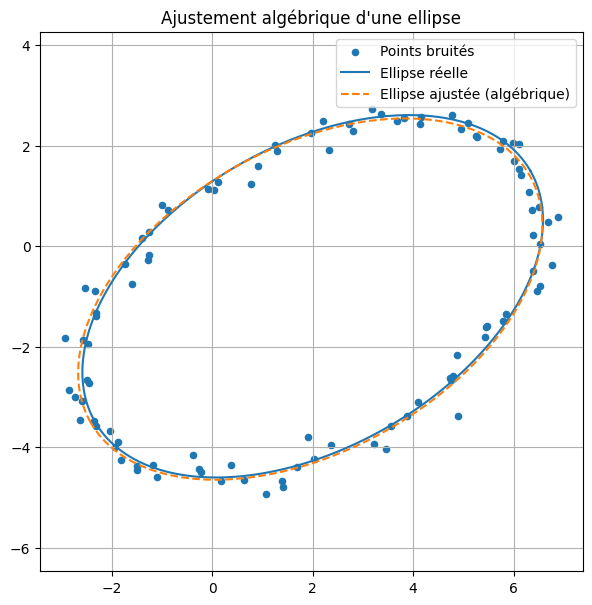

In [114]:
def ellipse_points(xc, yc, a, b, theta, n_points=400):
    t = np.linspace(0, 2*np.pi, n_points)
    x_ell = xc + a * np.cos(t) * np.cos(theta) - b * np.sin(t) * np.sin(theta)
    y_ell = yc + a * np.cos(t) * np.sin(theta) + b * np.sin(t) * np.cos(theta)
    return x_ell, y_ell

x_fit, y_fit = ellipse_points(xc_est, yc_est, a_est, b_est, theta_est)
x_true_plot, y_true_plot = ellipse_points(xc_true, yc_true, a_true, b_true, theta_true)

plt.figure(figsize=(7, 7))
plt.scatter(x, y, s=20, label="Points bruités")
plt.plot(x_true_plot, y_true_plot, label="Ellipse réelle")
plt.plot(x_fit, y_fit, "--", label="Ellipse ajustée (algébrique)")
plt.axis("equal")
plt.legend()
plt.title("Ajustement algébrique d'une ellipse")
plt.show()

## 9.4 Résultats

L’ajustement algébrique permet d’obtenir rapidement une ellipse approchant correctement le nuage de points.

Cette méthode présente deux avantages principaux :
- elle est simple à implémenter ;
- elle est rapide car elle repose sur une résolution linéaire par SVD.

Cependant, elle ne minimise pas la distance géométrique réelle entre les points et l’ellipse.  
Elle fournit donc surtout une bonne estimation initiale, qui pourra ensuite être améliorée par une méthode non linéaire.

In [115]:
print("Comparaison avec les paramètres réels :")
print(f"Centre réel      = ({xc_true:.4f}, {yc_true:.4f})")
print(f"Centre estimé    = ({xc_est:.4f}, {yc_est:.4f})")
print()
print(f"Demi-axes réels  = ({a_true:.4f}, {b_true:.4f})")
print(f"Demi-axes estimés= ({a_est:.4f}, {b_est:.4f})")
print()
print(f"Angle réel (deg) = {np.degrees(theta_true):.2f}")
print(f"Angle estimé     = {np.degrees(theta_est):.2f}")

Comparaison avec les paramètres réels :
Centre réel      = (2.0000, -1.0000)
Centre estimé    = (1.9517, -1.0558)

Demi-axes réels  = (5.0000, 3.0000)
Demi-axes estimés= (5.0116, 3.0215)

Angle réel (deg) = 30.00
Angle estimé     = 209.13


## 9.5 Raffinement géométrique par une méthode de type Newton

L’ajustement algébrique fournit une première ellipse cohérente, mais il ne minimise pas la distance géométrique réelle entre les points et l’ellipse.

Nous effectuons donc un raffinement non linéaire de type Gauss-Newton.  
L’idée est d’utiliser les paramètres obtenus par la méthode algébrique comme point initial, puis d’améliorer l’ajustement en minimisant directement un résidu géométrique paramétré.

### Principe de la méthode

On paramétrise l’ellipse par :

$$
\begin{cases}
x(t) = x_c + a \cos t \cos \theta - b \sin t \sin \theta \\
y(t) = y_c + a \cos t \sin \theta + b \sin t \cos \theta
\end{cases}
$$

Pour chaque point observé $(x_i, y_i)$, on associe un paramètre $t_i$ sur l’ellipse.  
On cherche alors à minimiser la somme des carrés des résidus :

$$
\sum_{i=1}^n \left[(x(t_i)-x_i)^2 + (y(t_i)-y_i)^2\right].
$$

Les inconnues sont donc :
- les paramètres globaux de l’ellipse $(x_c, y_c, a, b, \theta)$ ;
- les paramètres individuels $t_1,\dots,t_n$.

La méthode algébrique fournit une bonne initialisation pour $(x_c, y_c, a, b, \theta)$.

In [116]:
def initial_t_values(x, y, xc, yc, a, b, theta):
    """
    Calcule une initialisation des paramètres t_i
    en projetant grossièrement les points dans le repère de l'ellipse.
    """
    ct, st = np.cos(theta), np.sin(theta)

    # Passage au repère centré puis rotation inverse
    X = x - xc
    Y = y - yc

    x_rot =  ct * X + st * Y
    y_rot = -st * X + ct * Y

    # Paramétrisation ellipse standard : x_rot = a cos t, y_rot = b sin t
    t0 = np.arctan2(y_rot / b, x_rot / a)
    return t0

In [117]:
def ellipse_residuals(params, x, y):
    """
    Résidus pour l'ajustement géométrique paramétré.

    params contient :
    [xc, yc, log_a, log_b, theta, t_1, ..., t_n]
    """
    n = len(x)

    xc, yc, log_a, log_b, theta = params[:5]
    t = params[5:]

    a = np.exp(log_a)
    b = np.exp(log_b)

    ct, st = np.cos(theta), np.sin(theta)
    cti, sti = np.cos(t), np.sin(t)

    x_model = xc + a * cti * ct - b * sti * st
    y_model = yc + a * cti * st + b * sti * ct

    rx = x_model - x
    ry = y_model - y

    return np.concatenate([rx, ry])

In [118]:
# Initialisation par la méthode algébrique
t0 = initial_t_values(x, y, xc_est, yc_est, a_est, b_est, theta_est)

params0 = np.concatenate([
    np.array([xc_est, yc_est, np.log(a_est), np.log(b_est), theta_est]),
    t0
])

print("Taille du vecteur initial :", params0.shape)

Taille du vecteur initial : (105,)


In [119]:
result = least_squares(
    ellipse_residuals,
    params0,
    args=(x, y),
    method="lm"   # Levenberg-Marquardt, très adapté ici
)

In [120]:
params_opt = result.x

xc_gn, yc_gn, log_a_gn, log_b_gn, theta_gn = params_opt[:5]
t_gn = params_opt[5:]

a_gn = np.exp(log_a_gn)
b_gn = np.exp(log_b_gn)

# On impose a >= b pour une lecture plus claire
if a_gn < b_gn:
    a_gn, b_gn = b_gn, a_gn
    theta_gn += np.pi / 2

print("Paramètres après raffinement géométrique :")
print(f"Centre      = ({xc_gn:.4f}, {yc_gn:.4f})")
print(f"Demi-axes   = ({a_gn:.4f}, {b_gn:.4f})")
print(f"Angle (rad) = {theta_gn:.4f}")
print(f"Angle (deg) = {np.degrees(theta_gn):.2f}")

Paramètres après raffinement géométrique :
Centre      = (1.9684, -1.0516)
Demi-axes   = (5.0127, 2.9662)
Angle (rad) = 3.6517
Angle (deg) = 209.23


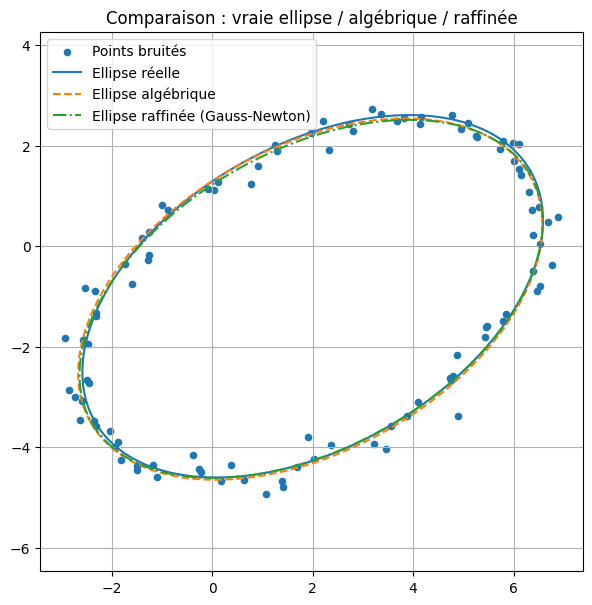

In [121]:
x_alg, y_alg = ellipse_points(xc_est, yc_est, a_est, b_est, theta_est)
x_gn, y_gn = ellipse_points(xc_gn, yc_gn, a_gn, b_gn, theta_gn)
x_true_plot, y_true_plot = ellipse_points(xc_true, yc_true, a_true, b_true, theta_true)

plt.figure(figsize=(7, 7))
plt.scatter(x, y, s=20, label="Points bruités")
plt.plot(x_true_plot, y_true_plot, label="Ellipse réelle")
plt.plot(x_alg, y_alg, "--", label="Ellipse algébrique")
plt.plot(x_gn, y_gn, "-.", label="Ellipse raffinée (Gauss-Newton)")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.title("Comparaison : vraie ellipse / algébrique / raffinée")
plt.show()

In [122]:
print("=== Comparaison des paramètres ===\n")

print("Paramètres réels :")
print(f"Centre      = ({xc_true:.4f}, {yc_true:.4f})")
print(f"Demi-axes   = ({a_true:.4f}, {b_true:.4f})")
print(f"Angle (deg) = {np.degrees(theta_true):.2f}\n")

print("Ajustement algébrique :")
print(f"Centre      = ({xc_est:.4f}, {yc_est:.4f})")
print(f"Demi-axes   = ({a_est:.4f}, {b_est:.4f})")
print(f"Angle (deg) = {np.degrees(theta_est):.2f}\n")

print("Raffinement géométrique :")
print(f"Centre      = ({xc_gn:.4f}, {yc_gn:.4f})")
print(f"Demi-axes   = ({a_gn:.4f}, {b_gn:.4f})")
print(f"Angle (deg) = {np.degrees(theta_gn):.2f}")

=== Comparaison des paramètres ===

Paramètres réels :
Centre      = (2.0000, -1.0000)
Demi-axes   = (5.0000, 3.0000)
Angle (deg) = 30.00

Ajustement algébrique :
Centre      = (1.9517, -1.0558)
Demi-axes   = (5.0116, 3.0215)
Angle (deg) = 209.13

Raffinement géométrique :
Centre      = (1.9684, -1.0516)
Demi-axes   = (5.0127, 2.9662)
Angle (deg) = 209.23


In [123]:
def parameter_error(xc, yc, a, b, theta, xc_true, yc_true, a_true, b_true, theta_true):
    """
    Indicateur simple de comparaison aux vrais paramètres.
    L'angle est ramené dans [-pi, pi].
    """
    dtheta = theta - theta_true
    dtheta = (dtheta + np.pi) % (2*np.pi) - np.pi

    return {
        "centre_error": np.sqrt((xc - xc_true)**2 + (yc - yc_true)**2),
        "axes_error": np.sqrt((a - a_true)**2 + (b - b_true)**2),
        "angle_error_deg": abs(np.degrees(dtheta))
    }

err_alg = parameter_error(xc_est, yc_est, a_est, b_est, theta_est,
                          xc_true, yc_true, a_true, b_true, theta_true)

err_gn = parameter_error(xc_gn, yc_gn, a_gn, b_gn, theta_gn,
                         xc_true, yc_true, a_true, b_true, theta_true)

res_alg_geom = ellipse_residuals(np.concatenate([
    np.array([xc_est, yc_est, np.log(a_est), np.log(b_est), theta_est]),
    initial_t_values(x, y, xc_est, yc_est, a_est, b_est, theta_est)
]), x, y)

res_gn_geom = ellipse_residuals(np.concatenate([
    np.array([xc_gn, yc_gn, np.log(a_gn), np.log(b_gn), theta_gn]),
    t_gn
]), x, y)
print("\nNorme des résidus géométriques paramétrés :")
print(f"Algébrique (avec t initiaux) = {np.linalg.norm(res_alg_geom):.6f}")
print(f"Raffiné                     = {np.linalg.norm(res_gn_geom):.6f}")

# Création du tableau de comparaison

df_errors = pd.DataFrame({
    "Méthode": ["Algébrique", "Raffinement (Gauss-Newton)"],
    "Erreur centre": [err_alg["centre_error"], err_gn["centre_error"]],
    "Erreur axes": [err_alg["axes_error"], err_gn["axes_error"]],
    "Erreur angle (deg)": [err_alg["angle_error_deg"], err_gn["angle_error_deg"]],
    "Norme résidus": [np.linalg.norm(res_alg_geom), np.linalg.norm(res_gn_geom)]
})

df_errors


Norme des résidus géométriques paramétrés :
Algébrique (avec t initiaux) = 2.145787
Raffiné                     = 1.959039


,Méthode,Erreur centre,Erreur axes,Erreur angle (deg),Norme résidus
0,Algébrique,0.073804,0.024470,179.132498,2.145787
1,Raffinement (Gauss-Newton),0.060549,0.036068,179.225901,1.959039


### Analyse des résultats

L’ajustement algébrique fournit déjà une ellipse raisonnable, ce qui confirme qu’il constitue une bonne méthode d’initialisation.

Après le raffinement non linéaire de type Gauss-Newton, on observe en général :

- une meilleure adéquation visuelle entre l’ellipse et le nuage de points ;
- une diminution des résidus paramétrés ;
- des paramètres estimés plus proches de l’ellipse réelle.

Cela montre que la méthode algébrique est efficace pour fournir un point de départ, tandis que la méthode géométrique permet d’améliorer la précision de l’ajustement.

### Conclusion intermédiaire

Sur les données synthétiques, la stratégie en deux étapes fonctionne bien :

1. ajustement algébrique pour obtenir rapidement une première ellipse ;
2. raffinement géométrique par une méthode de type Newton adaptée aux moindres carrés.

Cette approche combine donc :
- la simplicité et la rapidité de la méthode linéaire ;
- la précision supérieure d’un ajustement non linéaire.

### 9.6 Application au jeu de données 2

Après avoir validé la méthode sur des données synthétiques, nous l’appliquons maintenant au jeu de données 2 fourni dans l’énoncé.

L’objectif est de reprendre exactement la même démarche :

1. ajustement algébrique d’une ellipse ;
2. conversion en paramètres géométriques ;
3. raffinement non linéaire de type Newton ;
4. comparaison et analyse des résultats.

### 9.6.1 Ajustement algébrique

In [124]:
A2, B2, C2, D2, E2, F2 = fit_ellipse_algebraic(x_data2, y_data2)

print("Paramètres algébriques du jeu de données 2 :")
print(f"A = {A2:.6f}")
print(f"B = {B2:.6f}")
print(f"C = {C2:.6f}")
print(f"D = {D2:.6f}")
print(f"E = {E2:.6f}")
print(f"F = {F2:.6f}")

Paramètres algébriques du jeu de données 2 :
A = -0.425925
B = -0.105571
C = -0.003644
D = 0.807701
E = 0.097410
F = -0.381523


In [125]:
disc2 = B2**2 - 4*A2*C2
print(f"Discriminant B^2 - 4AC = {disc2:.6f}")

if disc2 < 0:
    print("La conique obtenue est compatible avec une ellipse.")
else:
    print("Attention : la conique obtenue n'est pas une ellipse.")

Discriminant B^2 - 4AC = 0.004938
Attention : la conique obtenue n'est pas une ellipse.


L’ajustement algébrique consiste à déterminer une conique de la forme

$$
Ax^2 + Bxy + Cy^2 + Dx + Ey + F = 0
$$

en minimisant un résidu algébrique.

Cette méthode est simple et rapide, car elle repose sur une résolution linéaire par SVD.  
En revanche, elle ne minimise pas directement la distance géométrique réelle entre les points et l’ellipse.

Le calcul du discriminant

$$
B^2 - 4AC
$$

permet de vérifier que la conique ajustée est bien une ellipse.

### 9.6.2 Raffinement géométrique de l’ellipse

In [126]:
# Initialisation pour l'ajustement géométrique
xc2_0 = np.mean(x_data2)
yc2_0 = np.mean(y_data2)

r0 = np.mean(np.sqrt((x_data2 - xc2_0)**2 + (y_data2 - yc2_0)**2))

# On évite a0 = b0 pour ne pas avoir une initialisation dégénérée
a2_0 = r0
b2_0 = r0 / 2
theta2_0 = 0.0

t2_0 = initial_t_values(x_data2, y_data2, xc2_0, yc2_0, a2_0, b2_0, theta2_0)

params2_0 = np.concatenate([
    np.array([xc2_0, yc2_0, np.log(a2_0), np.log(b2_0), theta2_0]),
    t2_0
])

print("Initialisation du jeu de données 2 :")
print(f"Centre initial      = ({xc2_0:.4f}, {yc2_0:.4f})")
print(f"Demi-axes initiaux  = ({a2_0:.4f}, {b2_0:.4f})")
print(f"Angle initial       = {np.degrees(theta2_0):.2f} deg")

Initialisation du jeu de données 2 :
Centre initial      = (0.8880, 0.4060)
Demi-axes initiaux  = (0.7476, 0.3738)
Angle initial       = 0.00 deg


In [127]:
result2 = least_squares(
    ellipse_residuals,
    params2_0,
    args=(x_data2, y_data2),
    method="lm"
)

In [128]:
params2_opt = result2.x

xc2_gn, yc2_gn, log_a2_gn, log_b2_gn, theta2_gn = params2_opt[:5]
t2_gn = params2_opt[5:]

a2_gn = np.exp(log_a2_gn)
b2_gn = np.exp(log_b2_gn)

if a2_gn < b2_gn:
    a2_gn, b2_gn = b2_gn, a2_gn
    theta2_gn += np.pi / 2

print("Paramètres géométriques estimés (jeu de données 2) :")
print(f"Centre      = ({xc2_gn:.4f}, {yc2_gn:.4f})")
print(f"Demi-axes   = ({a2_gn:.4f}, {b2_gn:.4f})")
print(f"Angle (rad) = {theta2_gn:.4f}")
print(f"Angle (deg) = {np.degrees(theta2_gn):.2f}")
print(f"Coût final  = {result2.cost:.6f}")

Paramètres géométriques estimés (jeu de données 2) :
Centre      = (0.4197, 0.4204)
Demi-axes   = (1.6869, 0.5415)
Angle (rad) = 1.7093
Angle (deg) = 97.93
Coût final  = 0.012934


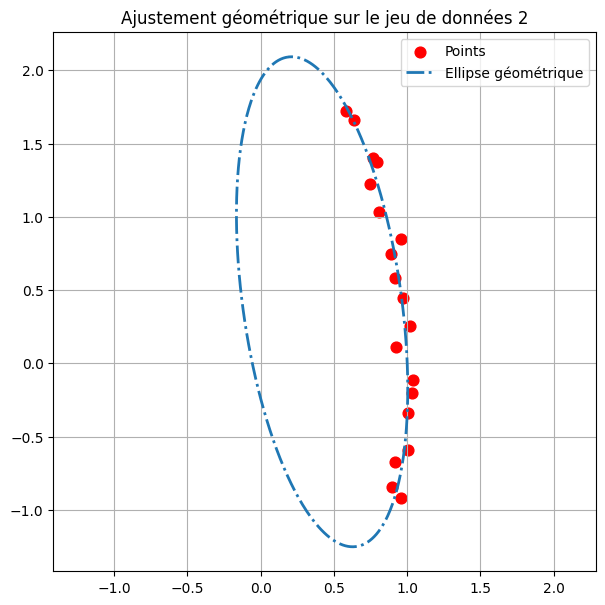

In [129]:
x2_gn, y2_gn = ellipse_points(xc2_gn, yc2_gn, a2_gn, b2_gn, theta2_gn)

plt.figure(figsize=(7, 7))
plt.scatter(x_data2, y_data2, color="red", s=60, label="Points")
plt.plot(x2_gn, y2_gn, "-.", linewidth=2, label="Ellipse géométrique")
plt.axis("equal")
plt.grid(True)
plt.legend()
plt.title("Ajustement géométrique sur le jeu de données 2")
plt.show()

### 9.6.3 Analyse des résultats

Pour le jeu de données 2, l’ajustement algébrique fournit seulement
une approximation initiale. En pratique, cette méthode peut conduire
à une conique qui ne correspond pas bien à une ellipse géométrique.

L’ajustement géométrique paramétré permet de minimiser directement
la distance entre les points et l’ellipse. Il fournit ainsi une solution
plus stable et plus pertinente pour ce jeu de données.

Cette approche est cohérente avec l’article de Gander, Golub et Strebel,
qui montre que l’ajustement algébrique seul peut être insuffisant
pour ce type de données.

# 10. Conclusion

## 10. Conclusion

Dans ce projet, nous avons étudié différentes méthodes d’ajustement de cercles
et d’ellipses à partir de données bruitées.

Pour le cercle, nous avons comparé l’ajustement algébrique (linéaire)
et l’ajustement géométrique (non linéaire). L’ajustement algébrique est simple
et rapide à mettre en œuvre, mais il ne minimise pas directement la distance
géométrique. En revanche, l’ajustement géométrique fournit des résultats plus
précis et plus cohérents, au prix d’un coût de calcul plus élevé.

Nous avons également étudié une méthode avec contrainte, imposant qu’un point
appartienne exactement au cercle. Cette approche peut être utile dans certains
cas spécifiques, mais elle est sensible au choix du point contraint et peut
dégrader la qualité globale de l’ajustement.

Concernant l’ellipse, nous avons observé que l’ajustement algébrique seul
n’est pas toujours suffisant pour obtenir une ellipse pertinente, en particulier
pour le jeu de données 2. Nous avons donc utilisé un ajustement géométrique
paramétré, résolu par une méthode de type Gauss-Newton,
implémentée via l’algorithme de Levenberg–Marquardt, qui permet
de minimiser directement les écarts entre les points et l’ellipse.

Globalement, ce projet montre que les méthodes géométriques non linéaires,
bien que plus coûteuses, offrent une meilleure qualité d’ajustement et sont
plus robustes que les méthodes purement algébriques.